# TERRA/MODIS Satellite SST visualization

**Purpose**: Code for visualizing MODIS SST 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from scipy.interpolate import griddata
from scipy.signal import detrend

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from spectra import spectrum1D_frequency, spectral_slope
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D

In [3]:
#--- Decorrelation Scale Analysis ---%
def compute_decor_scale_optimize(autocorr,x_ref,dx,bias,norm):

    """
    Computes the decorrelation scale as an intergral time scale from the positively lag autocorrelation function.  

    Parameters
    ----------
    autocorr : array
            Positive lag autocorrelation function. 

    x_ref : array 
            Lag time or distance independent variable. 

    dx : float 
            The distance between data points in physical space. 

    bias : str
            Specifies whether the covariance is biased or unbiased. The unbiased estimate is normalized by
            1/n-m whereas the biased estimate is normalized by 1/n where n = total number of data points in time
            series and m is the lag time from 0 lag. Options: 'biased' or 'unbiased'.

    norm : int
            Specifies which lagged covariance you want to normalize the autocovariance function by. The normal convention
            is to normalize it by the variance of the data record (the zeroth lag). However in the case where the noise in the
            measurements is causing a large drop in the autocorrelation from the zeroth lag to the first lag (introducing 
            a decorrelation signal different from the decorrelation from the natural variability of the system), normalizing the
            autocovariance function by the first lag will provide a more accurate decorrelation scale. Options includes 0 or 1 
            corresponds to the zero and first lag respectively. Default value: norm = 0. 

    Returns
    -------
    scale : float 
        The integral time scale estimate of the decorrelation scale. 

    Libraries necessary to run function
    -----------------------------------
    import numpy as np 
    from scipy.integrate import trapezoid

    """

    # Import libraries 
    import numpy as np
    from scipy.integrate import cumulative_trapezoid

    # Set the length of data series and data interval
    N = len(autocorr)      # length of one-sided autocorrelation function (and number of samples in data record)
    R = N * dx             # length of the data series (units of time or space)
    
    # Normalize by the zeroth lag 
    if norm == 0: 

        # Set the positive and negative lagged autocovariance functions and concatinate
        autocorr_full = np.concatenate((np.flip(autocorr[1:]), autocorr))
        x_ref_full    = np.concatenate((-1 * np.flip(x_ref[1:]), x_ref))

        # Precompute all possible trapezoidal integrals over the full symmetric autocorrelation function
        if bias == 'unbiased':
            
            # Compute triangular weights for unbiased estimator:
            # Each lag value is weighted by (1 - |lag| / R), which accounts for the decreasing number of data pairs at larger lags
            weights = 1 - (np.abs(x_ref_full) / R)
            
            # Multiply the symmetric autocorrelation function by the weights
            # This creates the weighted integrand to be used in integration
            integrand = weights * autocorr_full

        else:
            # If using biased estimator, do not apply weights; just use raw autocorrelation values
            integrand = autocorr_full

        # Interpolate over nans 
        if np.any(np.isnan(integrand)):

            # Find nan indices
            nans = np.isnan(integrand)

            # Linearly interpolate over nans
            integrand[nans] = np.interp(x_ref_full[nans], x_ref_full[~nans], integrand[~nans]) 

            # Define clean variable
            integrand_clean = integrand
        else: 
            integrand_clean = integrand

        # Compute the cumulative integral of the (possibly weighted) autocorrelation function
        # The result is a 1D array where each entry gives the integral from the first lag up to that point in x_ref_full
        # Setting initial=0 ensures the integral starts at zero
        integral_full = cumulative_trapezoid(integrand_clean, x_ref_full, initial=0)

        # Determine the index corresponding to zero lag in the full symmetric autocorrelation array
        center = N - 1  # Since autocorr_full has length 2N - 1, the center index is at N-1

        # Initialize an array to hold decorrelation scale estimates for each lag i
        scale_N = np.zeros(N)

        # Loop over lags from 1 to N-1 to compute integral estimates over symmetric windows
        for i in range(1, N):

            # Calculate the start index of the symmetric window for negative lag (-i)
            start = center - i

            # Calculate the end index (one past the positive lag +i) for slicing
            end = center + i + 1

            # Use cumulative trapezoidal integral differences to compute integral over [-i, +i]
            scale_N[i] = integral_full[end - 1] - integral_full[start]

        # Select the maximum value from all computed scales as a conservative estimate of the decorrelation scale
        scale = np.nanmax(scale_N)

    #--- Normalize by the first lag ---#
    if norm == 1:

        # For the positive lag autocorrelation function only, assuming symmetry around lag zero,
        # so the integral over negative lags can be accounted for by doubling the positive lag integral

        if bias == 'unbiased':

            # Compute triangular weights to correct for bias (fewer data pairs at larger lags)
            # weights linearly decrease from 1 at lag zero to 0 at maximum lag R
            weights = 1 - (x_ref / R)

            # Apply the weights to the autocorrelation values to get the weighted integrand
            integrand = weights * autocorr
        else:

            # If biased, no weighting; use the raw autocorrelation values
            integrand = autocorr

        # Compute the cumulative integral (trapezoidal rule) of the integrand over positive lags
        # integral_pos[k] holds the integral from lag zero up to lag x_ref[k]
        integral_pos = cumulative_trapezoid(integrand, x_ref, initial=0)

        # Initialize array to hold decorrelation scale estimates for each lag
        scale_N = np.zeros(N)

        # For lags greater than zero, scale the integral by 2 to account for symmetric negative lags
        scale_N[1:] = 2 * integral_pos[1:]

        # Take the maximum integral value as the conservative estimate of the decorrelation scale
        scale = np.nanmax(scale_N)

    return scale, scale_N

Set data analysis parameters

In [4]:
# Set time and space parametersf   
lat_bnds     = [33, 47.5]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-130 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/satellite/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set plotting parameters 
fontsize = 20

Load satellite data netcdf files 

In [5]:
#--- MITgcm Data ---# 
filename1 = PATH + "TERRA_MODIS.20241107T180000.L2.SST.nc"
filename2 = PATH + "TERRA_MODIS.20241107T180500.L2.SST.nc"
nc1 = Dataset(filename1, 'r')
nc2 = Dataset(filename2, 'r')

# Extract data variables
lat1 = nc1['navigation_data']['latitude'][:]
lon1 = nc1['navigation_data']['longitude'][:]
lat2 = nc2['navigation_data']['latitude'][:]
lon2 = nc2['navigation_data']['longitude'][:]

sst1      = nc1['geophysical_data']['sst'][:]        
qual_sst1 = nc1['geophysical_data']['qual_sst'][:]
sst2      = nc2['geophysical_data']['sst'][:]        
qual_sst2 = nc2['geophysical_data']['qual_sst'][:]

# Get fill value from attributes
fill_val1 = nc1['geophysical_data']['sst'].getncattr('_FillValue')
fill_val2 = nc2['geophysical_data']['sst'].getncattr('_FillValue')

# Mask data at fill values and anything below good quality
sst_masked1 = np.ma.masked_where((sst1 == fill_val1) | (~np.isin(qual_sst1, [0, 1])), sst1)
sst_masked2 = np.ma.masked_where((sst2 == fill_val2) | (~np.isin(qual_sst2, [0, 1])), sst2)

Read in bathymetry data

In [6]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Set plotting parameters

In [7]:
import cartopy.feature as cfeature
fontsize = 28

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Set plotting parameters for cartopy functions
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = np.arange(-128,-115,2) #[-123, -122, -121, -120]
yticks = np.arange(32,47.5,2) #[33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -128
lon_max = -115
lat_min = 30
lat_max = 47.5
cmap = 'Spectral_r' #cmo.thermal
levels = np.arange(11,20,0.1)

Plot satellite imagery

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


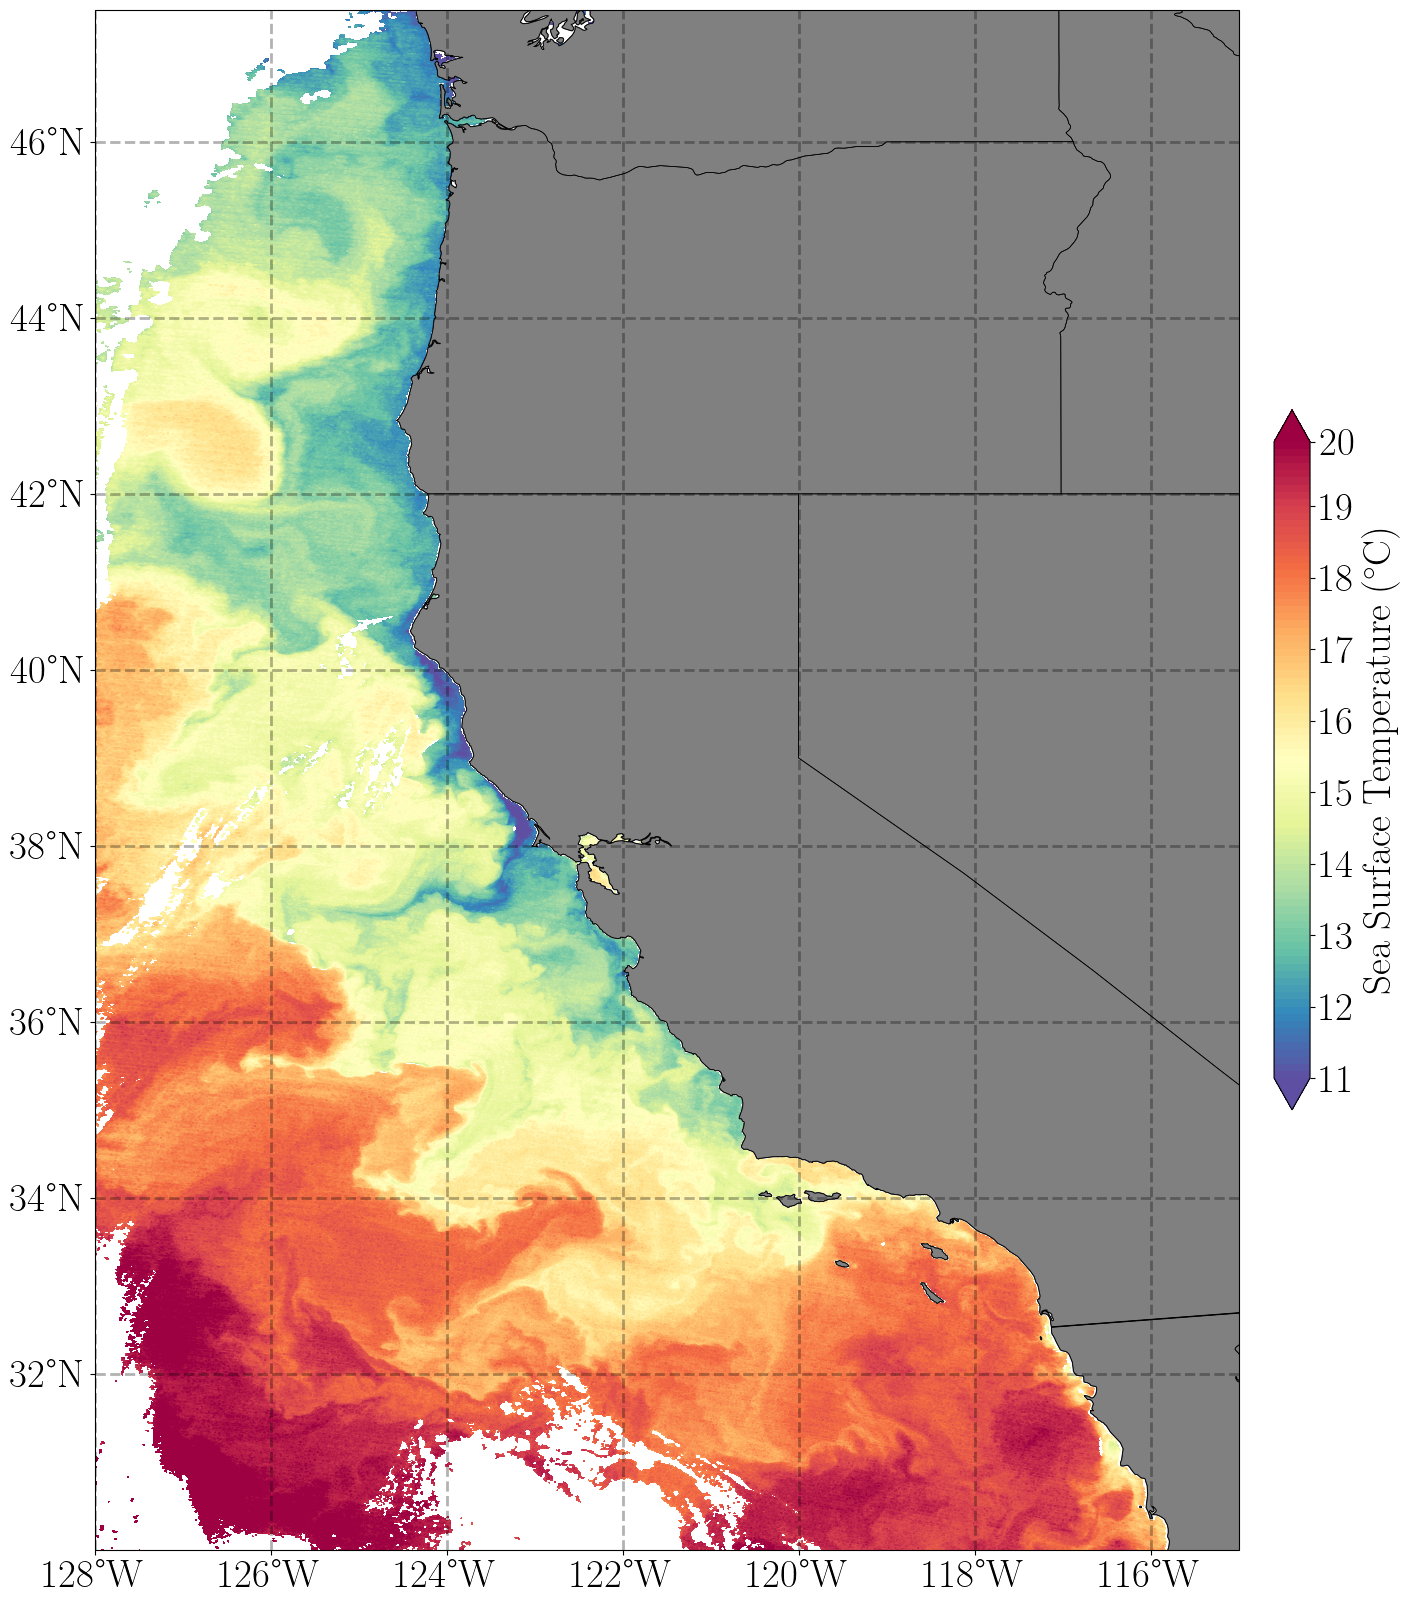

In [8]:
# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh1 = axes.contourf(
    lon1, lat1, sst_masked1, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    shading="auto", 
    extend = 'both'
)

mesh2 = axes.contourf(
    lon2, lat2, sst_masked2, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    shading="auto", 
    extend = 'both'
)

# Plot depth contour lines
# level_innershelf = np.arange(0,300,100)
# levels_midshelf = np.arange(1000,3000,500)
# contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
# contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
# contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
# contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
# plt.clabel(contour1, fontsize=12)
# plt.clabel(contour2, fontsize=12)
# plt.clabel(contour3, fontsize=12)
# plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colormap
cax = plt.axes([0.85, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh1,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label= r'Sea Surface Temperature ($^\circ$C)',
    nbins=10,
    fontsize=fontsize,
    cbar_ticks=[],
    task="regular",
)

# Add state and country borders plus rivers and lakes
axes.add_feature(cfeature.BORDERS, ls = '-', linewidth=1)        # country borders
axes.add_feature(cfeature.STATES, ls = '-', linewidth=0.5)       # US state borders
# axes.add_feature(cfeature.RIVERS, linewidth=0.7, edgecolor='blue')   # major rivers
# axes.add_feature(cfeature.LAKES, facecolor='none', edgecolor='blue') # optional: lakes

# Show the plot
plt.show()

In [8]:
# Set max and min values 
lon_min = -128 % 360
lon_max = -116 % 360
lat_min = 32
lat_max = 42

# Extract data from bathymetry 
lon_grid_n = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid_n = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid_n   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


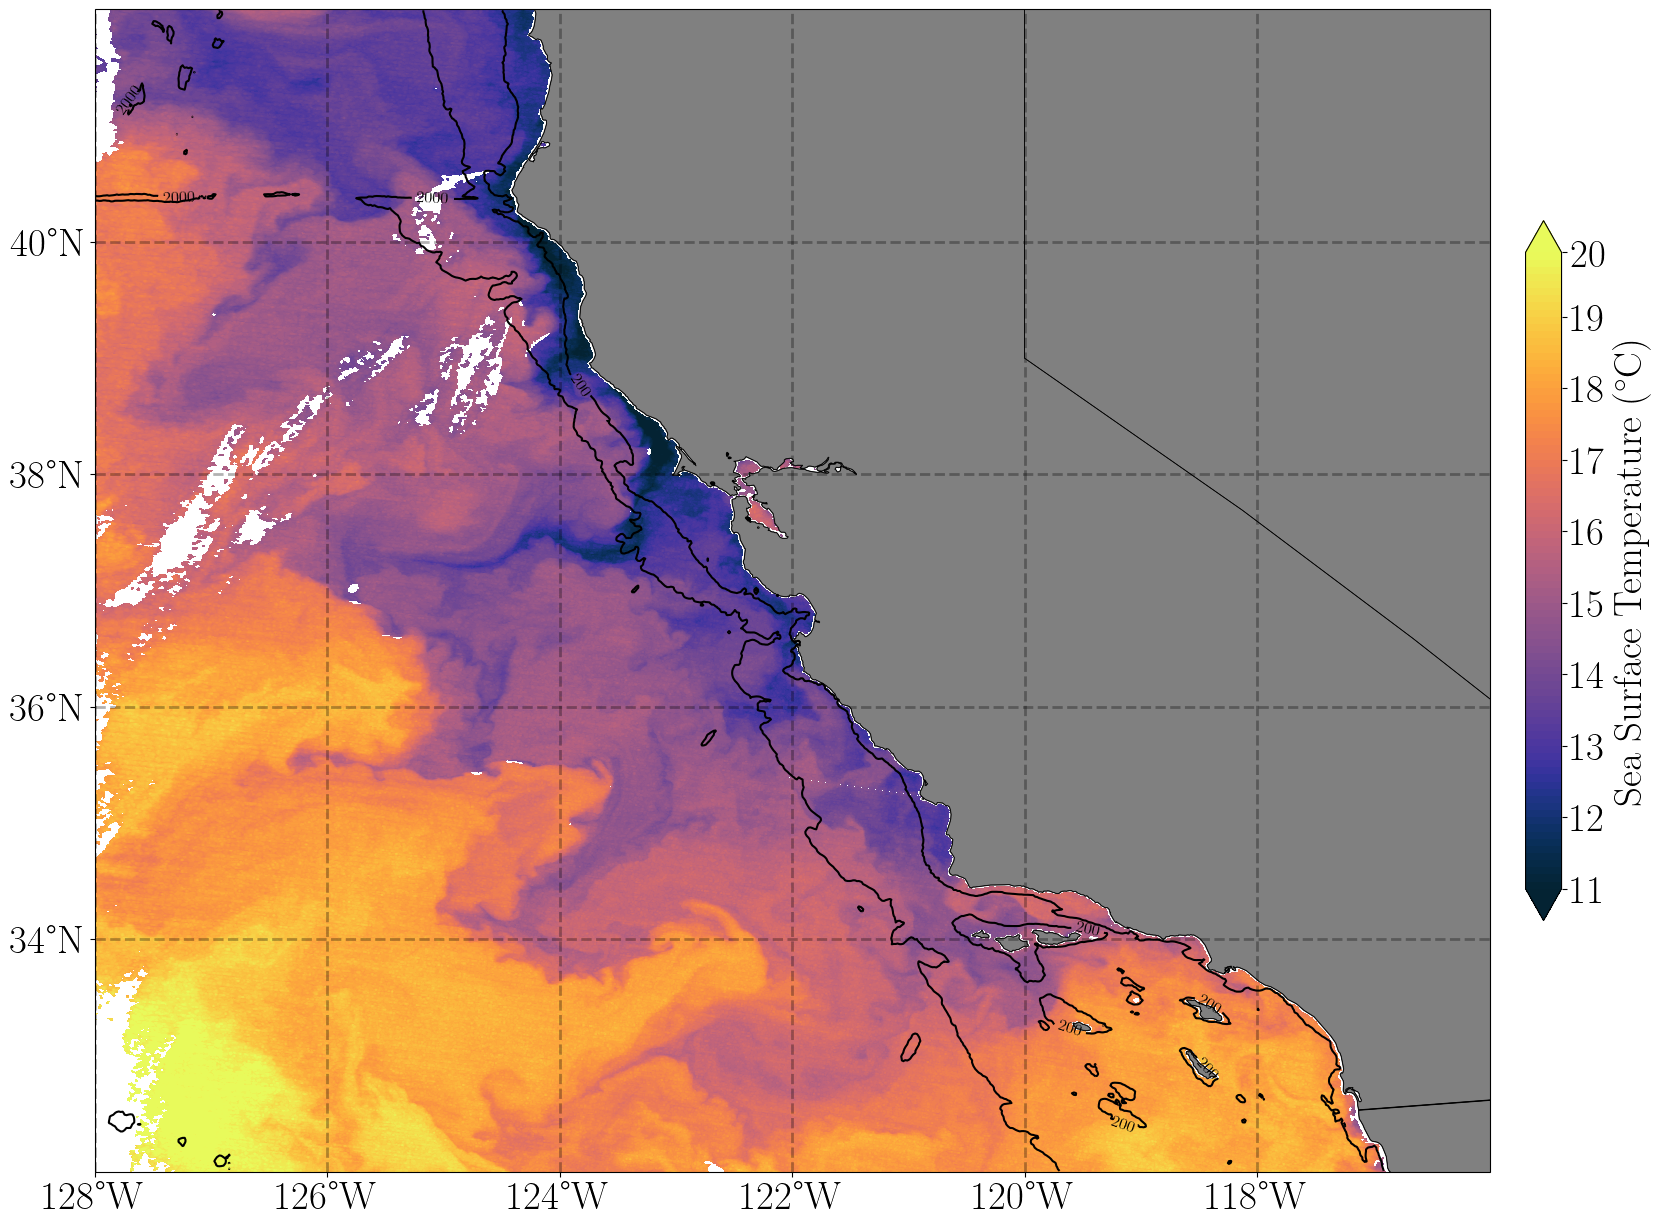

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


In [9]:
# Set plotting parameters for cartopy functions
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = np.arange(-128,-116,2) #[-123, -122, -121, -120]
yticks = np.arange(34,42,2) #[33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -128
lon_max = -116
lat_min = 32
lat_max = 42
cmap = cmo.thermal #'Spectral_r' #cmo.thermal
levels = np.arange(11,20,0.1)

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh1 = axes.contourf(
    lon1, lat1, sst_masked1, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

mesh2 = axes.contourf(
    lon2, lat2, sst_masked2, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap, 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(100,300,100)
levels_midshelf = np.arange(1000,3000,500)
#contour1 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[2000], colors='black', linewidths=1.5, linestyles='solid')
#contour3 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
#axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[500], colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[200], colors='black', linewidths=1.5, linestyles='solid')
# plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
# plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh1,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label= r'Sea Surface Temperature ($^\circ$C)',
    nbins=10,
    fontsize=fontsize,
    cbar_ticks=[],
    task="regular",
)

# Add state and country borders plus rivers and lakes
axes.add_feature(cfeature.BORDERS, ls = '-', linewidth=1)        # country borders
axes.add_feature(cfeature.STATES, ls = '-', linewidth=0.5)       # US state borders
# axes.add_feature(cfeature.RIVERS, linewidth=0.7, edgecolor='blue')   # major rivers
# axes.add_feature(cfeature.LAKES, facecolor='none', edgecolor='blue') # optional: lakes

# Show the plot
plt.show()

# Save figure in high resolution 
figName = 'fig01_osm.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Bound the ccs regional map, stitch the two sst images together, bound region of interest and interpolate onto a regular grid

In [9]:
# Create masks for the California Current System region
mask1 = (lon1 >= lon_min) & (lon1 <= lon_max) & (lat1 >= lat_min) & (lat1 <= lat_max)
mask2 = (lon2 >= lon_min) & (lon2 <= lon_max) & (lat2 >= lat_min) & (lat2 <= lat_max)

# Apply masks
lon1_ccs = lon1[mask1]
lat1_ccs = lat1[mask1]
sst1_ccs = sst_masked1[mask1]

lon2_ccs = lon2[mask2]
lat2_ccs = lat2[mask2]
sst2_ccs = sst_masked2[mask2]

# Concatenate the 1D arrays (stitch images together) 
lon_combined = np.concatenate([lon1_ccs, lon2_ccs])
lat_combined = np.concatenate([lat1_ccs, lat2_ccs])
sst_combined = np.concatenate([sst1_ccs, sst2_ccs])

# Define smaller ROI bounds
roi_lon_min, roi_lon_max = -126, -123
roi_lat_min, roi_lat_max = 34, 38

roi_mask = (lon_combined >= roi_lon_min) & (lon_combined <= roi_lon_max) & \
           (lat_combined >= roi_lat_min) & (lat_combined <= roi_lat_max)

lon_roi = lon_combined[roi_mask]
lat_roi = lat_combined[roi_mask]
sst_roi = sst_combined[roi_mask]

# Set the target solution 
target_dx = 1.0  # km in x (longitude) direction
target_dy = 1.0  # km in y (latitude) direction

# Latitude conversion
deg_per_km_lat = 1 / 111.32
dlat_deg = target_dy * deg_per_km_lat

# Longitude conversion (depends on latitude)
mean_lat_rad = np.deg2rad(np.mean(lat_roi))  # or a subset region
deg_per_km_lon = 1 / (111.32 * np.cos(mean_lat_rad))
dlon_deg = target_dx * deg_per_km_lon

# Define the target grid
grid_lon = np.arange(roi_lon_min, roi_lon_max + dlon_deg, dlon_deg)  # adjust resolution
grid_lat = np.arange(roi_lat_min, roi_lat_max + dlat_deg, dlat_deg)
grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

# Interpolate
sst_grid_linear = griddata(
    points=(lon_roi, lat_roi), 
    values=sst_roi, 
    xi=(grid_lon2d, grid_lat2d),
    method='linear'  # or 'nearest', 'cubic'
)

sst_grid_nearest = griddata(
    (lon_roi, lat_roi), sst_roi,
    (grid_lon2d, grid_lat2d),
    method='nearest'
)

# Replace NaNs from linear with nearest
sst_grid = np.where(np.isnan(sst_grid_linear), sst_grid_nearest, sst_grid_linear)


Plot the region of interest

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/cartopy_figs.py:246: UserWarning: Adding colorbar to a different Figure <Figure size 1800x2000 with 2 Axes> than <Figure size 1000x800 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cs, cax=cax, orientation=orientation, extend=extend)


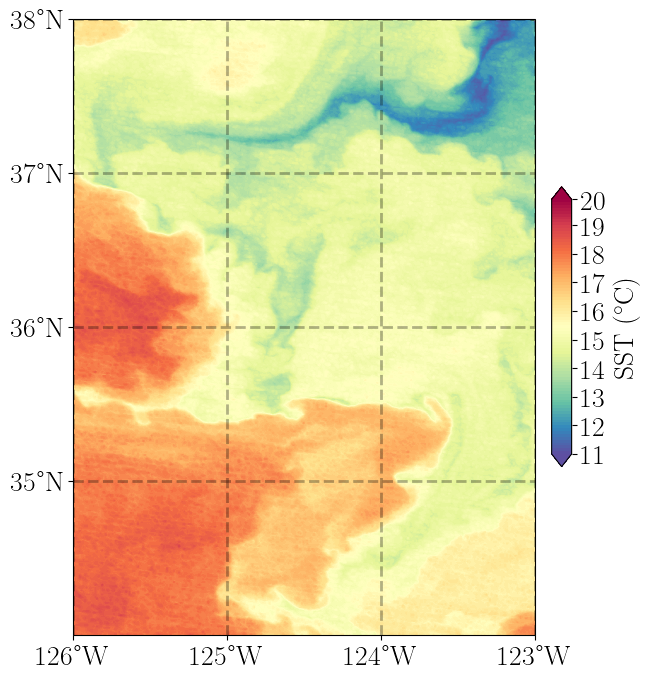

In [10]:
# Set fontsize
fontsize = 20

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Set plotting parameters for cartopy functions
xticks = np.arange(-126,-123+1,1) 
yticks = np.arange(35,38+1,1)
levels = np.arange(11,20,0.1)

# Create figure
fig, axes = plt.subplots(1,1, figsize=(10, 8), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=roi_lon_min, lon_max=roi_lon_max, lat_min=roi_lat_min, lat_max=roi_lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    grid_lon, grid_lat, sst_grid, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    shading="auto", 
    extend = 'both'
)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colormap
cax = plt.axes([0.76, 0.32, 0.02, 0.35])
cart.set_cbar(
    mesh1,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label= r'SST ($^\circ$C)',
    nbins=10,
    fontsize=fontsize,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Check the resolution of the image to compare with the target resolution

In [11]:
# Rough estimate of spacing in degrees
dlat = abs(np.mean(np.diff(lat1, axis=0)))  # along rows
dlon = abs(np.mean(np.diff(lon1, axis=1)))  # along columns

# Convert to units of kilometers
dlat_km = dlat * 111.32
mean_lat_rad = np.deg2rad(np.mean(lat1))
dlon_km = dlon * 111.32 * np.cos(mean_lat_rad)

print(dlat, dlon)
print(f"dlat ~ {dlat_km:.2f} km, dlon ~ {dlon_km:.2f} km")

0.008772228 0.020920405
dlat ~ 0.98 km, dlon ~ 1.67 km


## Example 1
Grab a slice of the region of interst which intersects through multiple interesting features

In [12]:
# Find the index closest to the target slice
target_lon = -124
idx = np.argmin(np.abs(grid_lon - target_lon))

# Grab the spatial record 
sst_1d = sst_grid[:,idx]

Plot the spatial record

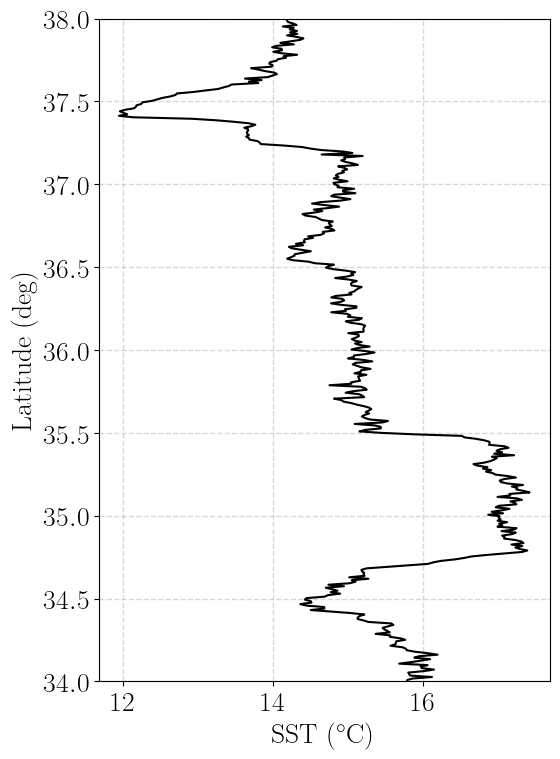

In [13]:
# Create figure
fig,ax = plt.subplots(figsize=(6,8))

# Plot the sst meridional record
ax.plot(sst_1d, grid_lat, ls='-', marker = '', color='k')

# Set axis attributes
ax.set_xlabel(r"SST ($^\circ$C)")
ax.set_ylabel("Latitude (deg)")
ax.set_ylim(34,38)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Compute the decorrelation scale

In [14]:
# Convert to distance relative to the first latitude
lat0 = grid_lat[0]
lat_km = (grid_lat - lat0) * 111.32
dlat_km = target_dy

# Set parameters for autocorrelation function
T = len(sst_1d)

# Detrend time series 
sst_dt = detrend(sst_1d)

# Compute autocorrelation function
autocorr, _, _, _, dist_scale, _ = compute_autocorr_optimize(sst_dt, lat_km, T, 'biased', 0)

# Compute the decorrelation scale numerically
L, I = compute_decor_scale_optimize(autocorr,dist_scale,dlat_km,'unbiased',0)

# Convert decorrelation scale back to degrees latitude
L_deg = (L / 111.32)

print(L)
print(L_deg)

39.62385144026728
0.35594548544976


Construct the two-sided Autocorrelation function

In [15]:
# Set the positive and negative lagged autocovariance functions
autocorr_pos = autocorr
autocorr_neg = np.flip(autocorr)[:-1]

# Set the positive and negative lag variable
x_ref_pos = dist_scale
x_ref_neg = -1 * np.flip(dist_scale)[:-1]

# Concatinate for two-sided autocorrelation
coef = np.concatenate((autocorr_neg, autocorr_pos))
x    = np.concatenate((x_ref_neg, x_ref_pos))

Plot the autocorrelation function along with the decorrelation scale

In [16]:
# Find the mask for the domain where we integrate 
idx = np.argmin(abs(x_ref_pos - np.argmax(I)))

# Apply mask to lag and autocorrelation
x_int_pos = x_ref_pos[:idx]
x_int_neg = -1 * np.flip(x_int_pos)[:-1]

autocorr_int_pos = autocorr[:idx]
autocorr_int_neg = np.flip(autocorr_int_pos)[:-1]

# Concatinate for two-sided autocorrelation
coef_int = np.concatenate((autocorr_int_neg, autocorr_int_pos))
x_int    = np.concatenate((x_int_neg, x_int_pos))

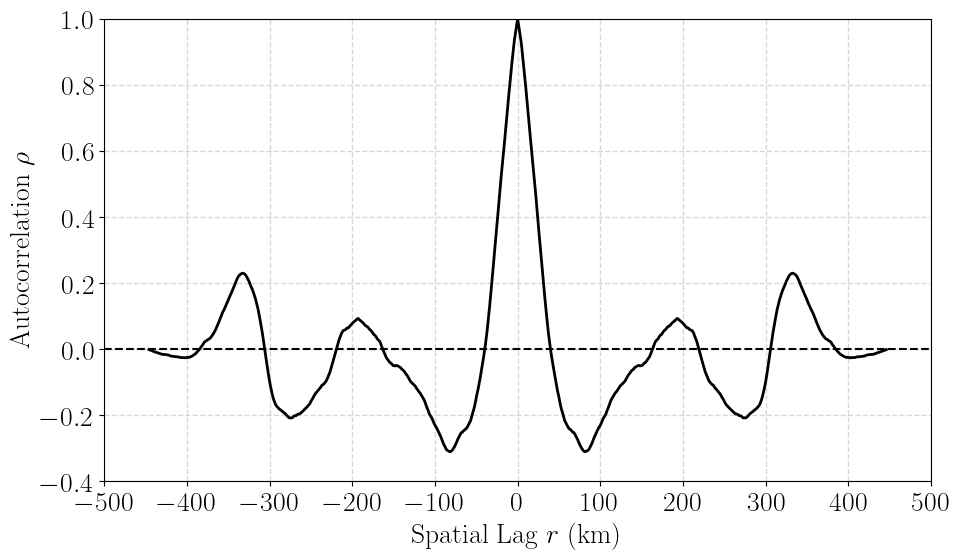

In [17]:
# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot the sst meridional record
ax.plot(x, coef, ls='-', lw=2, marker = '', color='k')
ax.axhline(0,ls='--',lw=1.5,color='k')

# # Shade integration region
# ax.fill_between(x_int, coef_int, 0,
#                 color='tab:blue', alpha=0.25, label='Integral scale')

# # Annotation pointing into the shaded region
# ax.annotate(f'Decorrelation scale $L$\n({L:.1f} km)',
#             xy=(0, 1/2),      # point halfway into shaded region
#             xycoords='data',
#             xytext=(10, 30),          # offset of text
#             textcoords='offset points',
#             ha='left', color='k',
#             arrowprops=dict(arrowstyle="->", color='tab:red', lw=2))

# Set axis attributes
ax.set_xlabel(r'Spatial Lag $r$ (km)' )
ax.set_ylabel(r'Autocorrelation $\rho$')
ax.set_xticks(np.arange(-500,500+100,100))
ax.set_ylim(-0.4,1)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

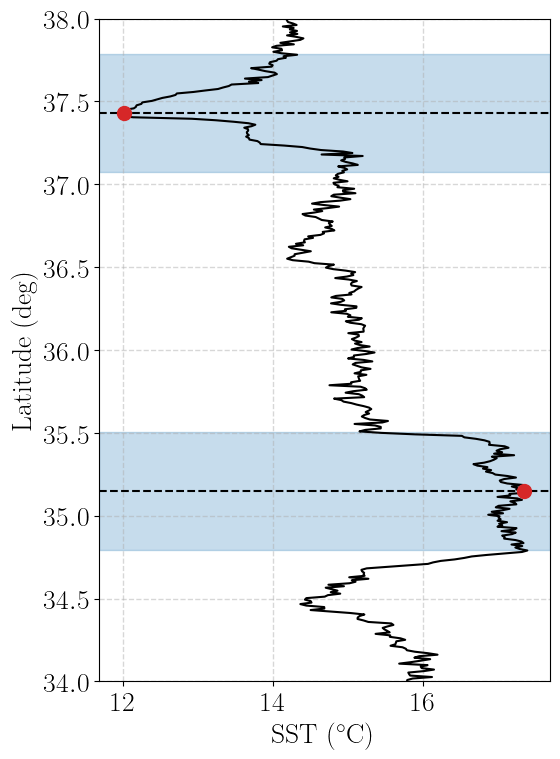

In [18]:
# Create figure
fig,ax = plt.subplots(figsize=(6,8))

# Plot the sst meridional record
ax.plot(sst_1d, grid_lat, ls='-', marker = '', color='k')

# Plot markers at the center of each feature
feature1_loc = 37.43
idx_loc1 = np.argmin(abs(grid_lat - feature1_loc))
ax.axhline(grid_lat[idx_loc1], ls='--',lw=1.5,color='k')
ax.plot(sst_1d[idx_loc1], grid_lat[idx_loc1], ls='', marker = 'o', ms=10, color='tab:red')

feature2_loc = 35.15
idx_loc2 = np.argmin(abs(grid_lat - feature2_loc))
ax.axhline(grid_lat[idx_loc2], ls='--',lw=1.5,color='k')
ax.plot(sst_1d[idx_loc2], grid_lat[idx_loc2], ls='', marker = 'o', ms=10, color='tab:red')

# Shade around the features
ax.axhspan(grid_lat[idx_loc1] - L_deg,
           grid_lat[idx_loc1] + L_deg,
           color='tab:blue', alpha=0.25, label='Decorrelation scale')

ax.axhspan(grid_lat[idx_loc2] - L_deg,
           grid_lat[idx_loc2] + L_deg,
           color='tab:blue', alpha=0.25, label='Decorrelation scale')

# Set axis attributes
ax.set_xlabel(r"SST ($^\circ$C)")
ax.set_ylabel("Latitude (deg)")
ax.set_ylim(34,38)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

## Example 2
Grab a slice of the region of interst which intersects through multiple interesting features

In [24]:
# Find the index closest to the target slice
target_lon = -124
target_lat = [34.0, 36.5]
idx_lon = np.argmin(np.abs(grid_lon - target_lon))
idx_lat = (grid_lat >= target_lat[0]) & (grid_lat <= target_lat[1])

# Grab the spatial record 
lat_1d = grid_lat[idx_lat]
sst_1d = sst_grid[idx_lat,idx_lon]

Plot the spatial record

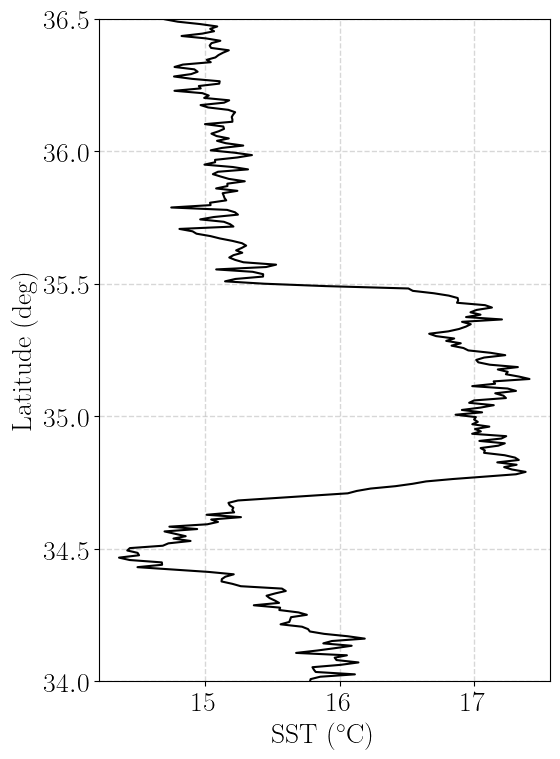

In [26]:
# Create figure
fig,ax = plt.subplots(figsize=(6,8))

# Plot the sst meridional record
ax.plot(sst_1d, lat_1d, ls='-', marker = '', color='k')

# Set axis attributes
ax.set_xlabel(r"SST ($^\circ$C)")
ax.set_ylabel("Latitude (deg)")
ax.set_ylim(34,36.5)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Compute the decorrelation scale

In [ ]:
# Convert to distance relative to the first latitude
lat0 = lat_1d[0]
lat_km = (lat_1d - lat0) * 111.32
dlat_km = target_dy

# Set parameters for autocorrelation function
T = len(sst_1d)

# Detrend time series 
sst_dt = detrend(sst_1d)

# Compute autocorrelation function
autocorr, _, _, _, dist_scale, _ = compute_autocorr_optimize(sst_dt, lat_km, T, 'biased', 0)

# Compute the decorrelation scale numerically
L, I = compute_decor_scale_optimize(autocorr,dist_scale,dlat_km,'unbiased',0)

# Convert decorrelation scale back to degrees latitude
L_deg = (L / 111.32)

print(L)
print(L_deg)



44.679908275462985
0.40136460901422016


Construct the two-sided Autocorrelation function

In [29]:
# Set the positive and negative lagged autocovariance functions
autocorr_pos = autocorr
autocorr_neg = np.flip(autocorr)[:-1]

# Set the positive and negative lag variable
x_ref_pos = dist_scale
x_ref_neg = -1 * np.flip(dist_scale)[:-1]

# Concatinate for two-sided autocorrelation
coef = np.concatenate((autocorr_neg, autocorr_pos))
x    = np.concatenate((x_ref_neg, x_ref_pos))

Plot the autocorrelation function along with the decorrelation scale

In [30]:
# Find the mask for the domain where we integrate 
idx = np.argmin(abs(x_ref_pos - np.argmax(I)))

# Apply mask to lag and autocorrelation
x_int_pos = x_ref_pos[:idx]
x_int_neg = -1 * np.flip(x_int_pos)[:-1]

autocorr_int_pos = autocorr[:idx]
autocorr_int_neg = np.flip(autocorr_int_pos)[:-1]

# Concatinate for two-sided autocorrelation
coef_int = np.concatenate((autocorr_int_neg, autocorr_int_pos))
x_int    = np.concatenate((x_int_neg, x_int_pos))

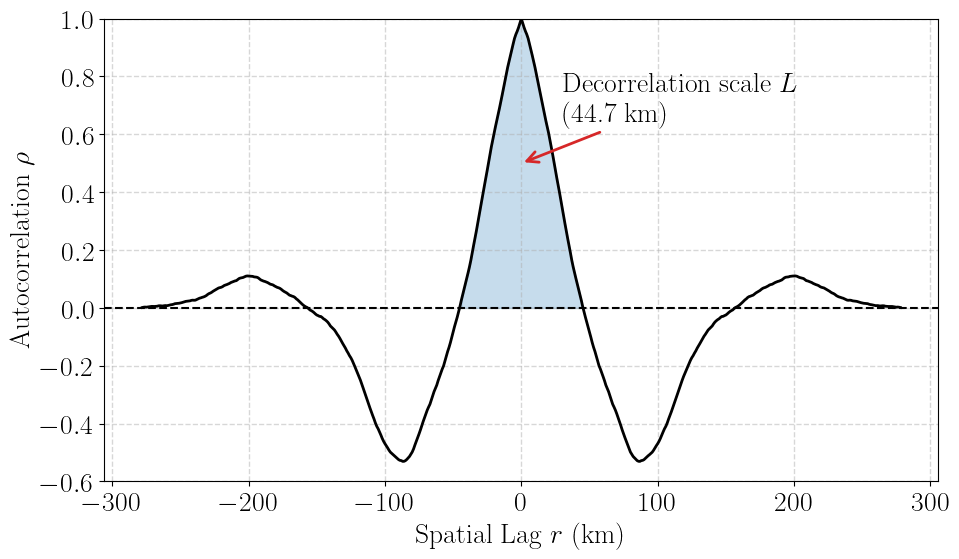

In [35]:
# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot the sst meridional record
ax.plot(x, coef, ls='-', lw=2, marker = '', color='k')
ax.axhline(0,ls='--',lw=1.5,color='k')

# Shade integration region
ax.fill_between(x_int, coef_int, 0,
                color='tab:blue', alpha=0.25, label='Integral scale')

# Annotation pointing into the shaded region
ax.annotate(f'Decorrelation scale $L$\n({L:.1f} km)',
            xy=(0, 1/2),      # point halfway into shaded region
            xycoords='data',
            xytext=(30, 30),          # offset of text
            textcoords='offset points',
            ha='left', color='k',
            arrowprops=dict(arrowstyle="->", color='tab:red', lw=2))

# Set axis attributes
ax.set_xlabel(r'Spatial Lag $r$ (km)' )
ax.set_ylabel(r'Autocorrelation $\rho$')
ax.set_xticks(np.arange(-300,300+100,100))
ax.set_ylim(-0.6,1)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

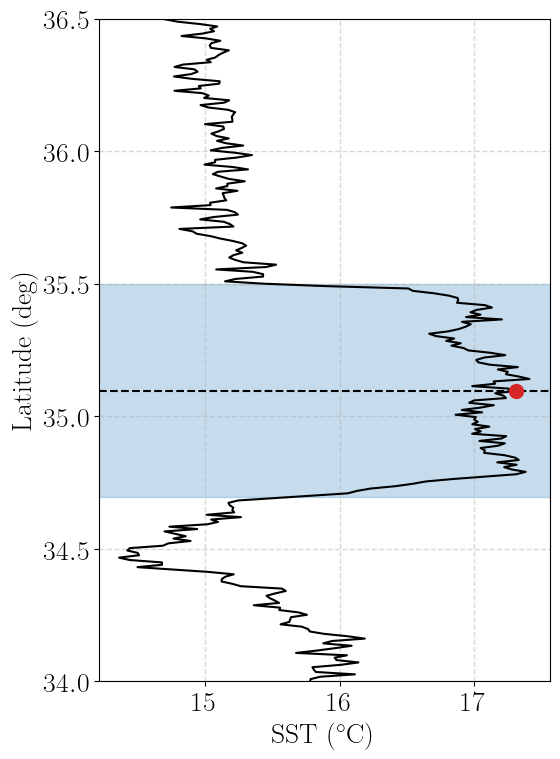

In [37]:
# Create figure
fig,ax = plt.subplots(figsize=(6,8))

# Plot the sst meridional record
ax.plot(sst_1d, lat_1d, ls='-', marker = '', color='k')

# Plot markers at the center of each feature
feature2_loc = 35.1
idx_loc2 = np.argmin(abs(lat_1d - feature2_loc))
ax.axhline(lat_1d[idx_loc2], ls='--',lw=1.5,color='k')
ax.plot(sst_1d[idx_loc2], lat_1d[idx_loc2], ls='', marker = 'o', ms=10, color='tab:red')

# Shade around the features
ax.axhspan(lat_1d[idx_loc2] - L_deg,
           lat_1d[idx_loc2] + L_deg,
           color='tab:blue', alpha=0.25, label='Decorrelation scale')

# Set axis attributes
ax.set_xlabel(r"SST ($^\circ$C)")
ax.set_ylabel("Latitude (deg)")
ax.set_ylim(34,36.5)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()